### How noise affects the postprocessing

We study this through three tests:

1. **Single-realization visual test**
   - compare the no-noise case with moderate and large noise,
   - visualize the DG and SIAC reconstructions and their error fields.

2. **Noise sweep with scalar errors**
   - for a single realization at each noise level, plot the relative $L^2$ and $L^\infty$ errors of the DG and SIAC solutions as functions of the noise level.

3. **Monte Carlo robustness study**
   - for each noise level, repeat the experiment over several independent noise realizations,
   - compute the mean and standard deviation of the relative $L^2$ and $L^\infty$ errors,
   - plot the mean error versus noise level with error bars or shaded bands to quantify robustness and variability.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [14]:
from src.mesh import build_uniform_mesh_2d
from src.grid import local_cell_center_nodes_1d, build_grid_from_local_nodes_2d
from src.testing.helpers_2d import (
    run_noise_trial_2d, 
    run_noise_sweep_2d, 
    run_noise_monte_carlo_2d, 
    plot_noise_trial_quad
    )


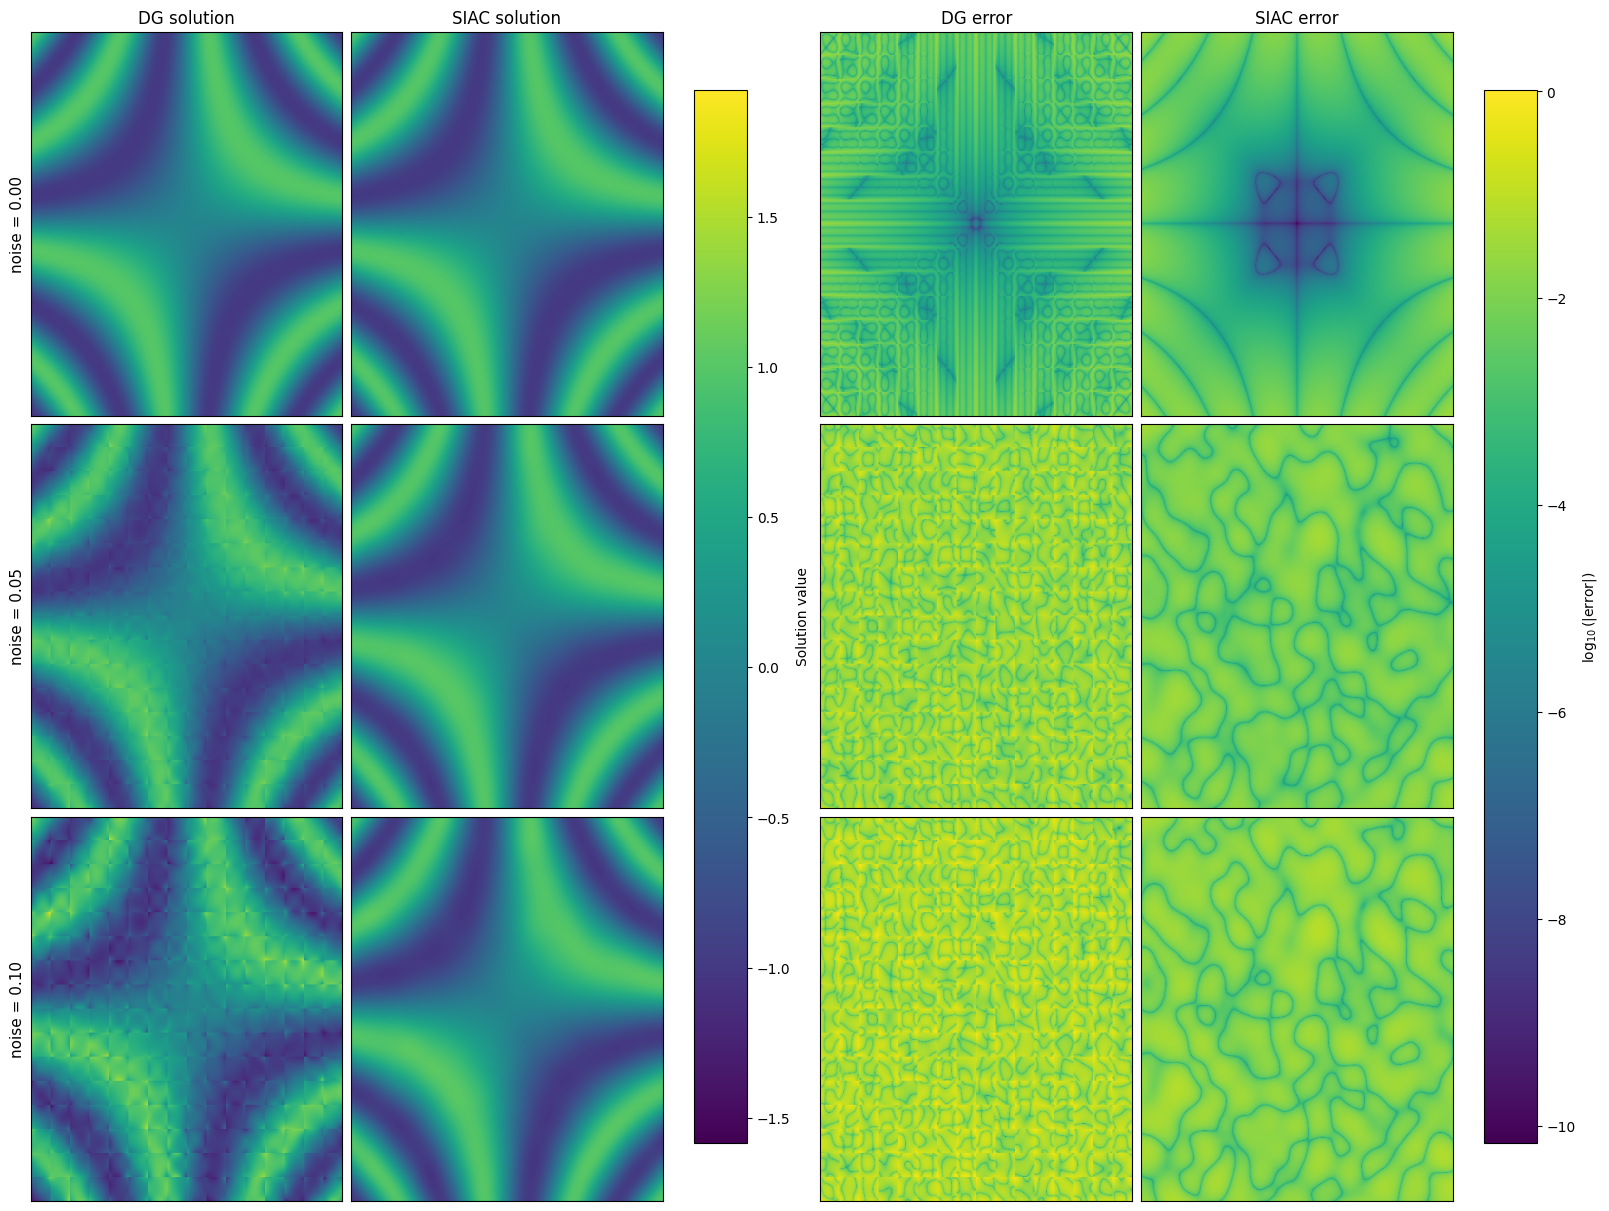

In [15]:
### Setup ###

# -----------------------------
# 0. Problem / domain setup
# -----------------------------
xmin, xmax = -2, 2
ymin, ymax = -2, 2
xlim = (xmin, xmax)
ylim = (ymin, ymax)

# --------------------------------------------------
# 1. Exact polynomial test function
# --------------------------------------------------
def exact_sine(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    u = np.sin(2*np.pi*x*y)
    return u

p = 2
order = p + 1

# DG mesh resolution
Kx, Ky = 24, 24

# SIAC parameters
moments = 2*p
BSorder = p + 1

# -----------------------------
# 2. Build DG mesh
# -----------------------------
mesh = build_uniform_mesh_2d(Kx, Ky, p=p, xlim=xlim, ylim=ylim)

# -----------------------------
# 3. Create sample grid
# -----------------------------
n_eval = order
nodes = local_cell_center_nodes_1d(n_eval)
X, Y = build_grid_from_local_nodes_2d(
    mesh,
    eval_nodes=nodes
)

# -----------------------------
# 3. Sample function and transform to nodal
# -----------------------------
arr = exact_sine(X, Y)
Unode = arr.reshape(Ky, order, Kx, order).transpose(0, 2, 1, 3)


# -----------------------------
# 4. Run trial for no, moderate, and high noise levels
# -----------------------------

res_clean = run_noise_trial_2d(
    exact_func=exact_sine, Unode_clean=Unode, mesh=mesh,
    p=p, moments=moments, BSorder=BSorder,
    noise_level=0.00, seed=1, return_full=True
)

res_mid = run_noise_trial_2d(
    exact_func=exact_sine, Unode_clean=Unode, mesh=mesh,
    p=p, moments=moments, BSorder=BSorder,
    noise_level=0.05, seed=1, return_full=True
)

res_high = run_noise_trial_2d(
    exact_func=exact_sine, Unode_clean=Unode, mesh=mesh,
    p=p, moments=moments, BSorder=BSorder,
    noise_level=0.10, seed=1, return_full=True
)

plot_noise_trial_quad(
    results=[res_clean, res_mid, res_high],
    noise_levels=[0.00, 0.05, 0.10]
)

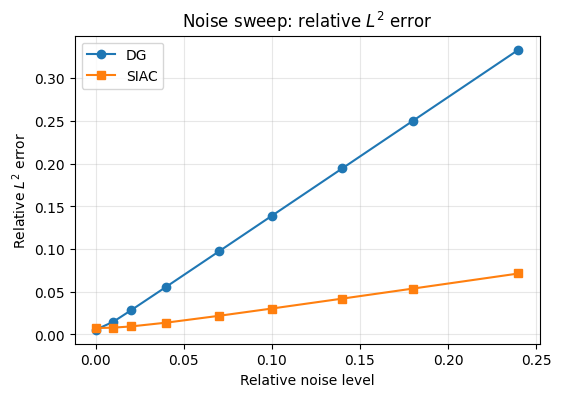

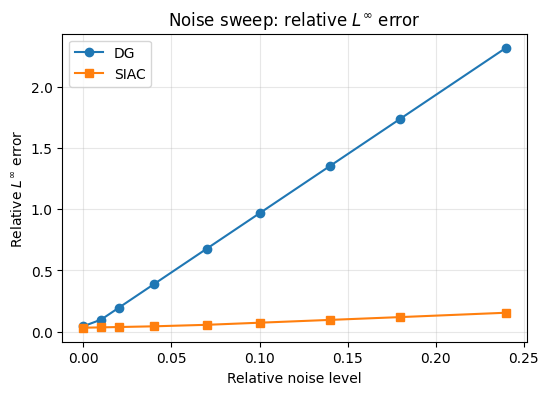

In [16]:
noise_levels = [0.00, 0.01, 0.02, 0.04, 0.07, 0.10, 0.14, 0.18, 0.24]

sweep = run_noise_sweep_2d(
    exact_func=exact_sine,
    Unode_clean=Unode,
    mesh=mesh,
    p=p,
    moments=moments,
    BSorder=BSorder,
    noise_levels=noise_levels,
    seed=42,
)

noise = [r["noise_level"] for r in sweep]
dg_l2 = [r["dg_rel_l2"] for r in sweep]
siac_l2 = [r["siac_rel_l2"] for r in sweep]

dg_linf = [r["dg_rel_linf"] for r in sweep]
siac_linf = [r["siac_rel_linf"] for r in sweep]

plt.figure(figsize=(6, 4))
plt.plot(noise, dg_l2, marker="o", label="DG")
plt.plot(noise, siac_l2, marker="s", label="SIAC")
plt.xlabel("Relative noise level")
plt.ylabel("Relative $L^2$ error")
plt.title("Noise sweep: relative $L^2$ error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(noise, dg_linf, marker="o", label="DG")
plt.plot(noise, siac_linf, marker="s", label="SIAC")
plt.xlabel("Relative noise level")
plt.ylabel("Relative $L^\infty$ error")
plt.title("Noise sweep: relative $L^\infty$ error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:

n_trials = 20   # takes around n_trials times longer than previous cell

mc = run_noise_monte_carlo_2d(
    exact_func=exact_sine,
    Unode_clean=Unode,
    mesh=mesh,
    p=p,
    moments=moments,
    BSorder=BSorder,
    noise_levels=noise_levels,
    n_trials=n_trials,
    base_seed=100,
)


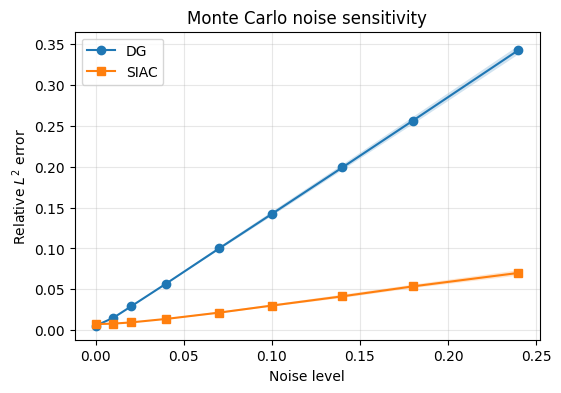

In [18]:

summary = mc["summary"]

noise = summary["noise_level"].to_numpy()

dg_mean = summary["dg_rel_l2_mean"].to_numpy()
dg_std = summary["dg_rel_l2_std"].fillna(0.0).to_numpy()

siac_mean = summary["siac_rel_l2_mean"].to_numpy()
siac_std = summary["siac_rel_l2_std"].fillna(0.0).to_numpy()

plt.figure(figsize=(6, 4))

plt.plot(noise, dg_mean, marker="o", label="DG")
plt.fill_between(
    noise,
    dg_mean - dg_std,
    dg_mean + dg_std,
    alpha=0.2,
)

plt.plot(noise, siac_mean, marker="s", label="SIAC")
plt.fill_between(
    noise,
    siac_mean - siac_std,
    siac_mean + siac_std,
    alpha=0.2,
)

plt.legend()
plt.xlabel("Noise level")
plt.ylabel("Relative $L^2$ error")
plt.title("Monte Carlo noise sensitivity")
plt.grid(True, alpha=0.3)
plt.show()